# STGAN geografico su PVGIS

Workflow riproducibile per preparare i dati 2005–2018, addestrare STGAN e produrre score geografici per il 2019. L'architettura segue Deng et al., *Graph Convolutional Adversarial Networks for Spatiotemporal Anomaly Detection* (TNNLS 2022, DOI `10.1109/TNNLS.2021.3136171`) e il repository ufficiale `dleyan/STGAN`, verificato al commit `20d2f6b`.

Il notebook richiama direttamente le funzioni Python del progetto: non costruisce comandi e non avvia processi esterni. Nessuna label di anomalia viene caricata durante training, normalizzazione, scoring o ranking.

In [1]:
from dataclasses import replace
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'pyproject.toml').is_file() and (ROOT.parent / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Eseguire il notebook dalla root del repository o da notebooks/.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from physiq_pv.anomaly_detection.pvgis_climate import prepare_pvgis_climate_data
from physiq_pv.anomaly_detection.stgan import (
    REFERENCE_CONFIG,
    REFERENCE_SEED,
    build_geographical_subgraphs,
)
from scripts.run_pvgis_stgan import run_stgan

if 'PVGIS_DIR' in os.environ:
    PVGIS_DIR = Path(os.environ['PVGIS_DIR']).resolve()
else:
    pvgis_candidates = (
        Path('/data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance'),
        ROOT / 'data' / 'pvgis',
    )
    PVGIS_DIR = next((path.resolve() for path in pvgis_candidates if path.is_dir()),
                     pvgis_candidates[-1].resolve())
WORK_ROOT = (ROOT / 'outputs' / 'pvgis_stgan').resolve()
PREPARED_DIR = WORK_ROOT / 'prepared'
MANIFEST = PREPARED_DIR / 'manifest.csv'
REFERENCE_OUTPUT = WORK_ROOT / 'paper_reference'
SMOKE_OUTPUT = WORK_ROOT / 'smoke'
DEVICE = 'cuda'
PAPER_TOP_K_PERCENT = 1.0

RUN_PREPARATION = True
RUN_SMOKE = True
RUN_REFERENCE = True
print('Repository:', ROOT)
print('PVGIS:', PVGIS_DIR)

Repository: /home/apedalino/physiq_pv
PVGIS: /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance


## Corrispondenza con paper e repository

| Elemento | Paper/repository | Implementazione PVGIS |
|---|---|---|
| Nodi | località/sensori | località PVGIS |
| Sottografo | nodo centrale + 8 vicini | identico, `K=9` |
| Grafo | topologia fisica, sottografo con 8 vicini | KNN geografico diretto con 8 vicini, adattamento dichiarato |
| Pesi | `exp(-d²/σ²)`, σ deviazione standard | identico, distanze Haversine |
| Normalizzazione | min-max training in `[-1,1]` | identica e training-only |
| Recent | un'ora per PeMS | un timestamp orario |
| Trend | sette giorni | 168 timestamp orari; il test usa la coda del train come contesto |
| External | weekday + hour, 31 dimensioni su PeMS | identico |
| GCGRU | 2 layer, 32 unità | identico |
| LSTM/altri layer | 2 layer, 64 unità | identico |
| GAN target | reale/normal=0, generato/fake=1 | identico |
| Loss G | `500*MSE + BCE(fake, normal)` | identica |
| Loss D | media BCE reale/fake | identica |
| Score | `sG + λ*sD`, componenti normalizzate, λ=1 | min-max globale separato sul test, λ=1 |
| Training | 6 epoche, batch 256, Adam 1e-3, seed 20 | identico |

Adattamento esplicito: PVGIS non possiede una rete stradale, quindi il grafo usa sempre un KNN geografico diretto con otto vicini. Il runner applica unicamente il ranking globale top-K% del paper. Gli score per feature sono diagnostici aggiuntivi e non una diagnosi causale.

In [2]:
paper_config = REFERENCE_CONFIG.to_dict()
paper_config['seed'] = REFERENCE_SEED
pd.Series(paper_config, name='valore').to_frame()

,valore
epochs,6.000
batch_size,256.000
learning_rate,0.001
generator_reconstruction_weight,500.000
hidden_size,64.000
n_layers,2.000
subgraph_size,9.000
recent_steps,1.000
trend_steps,168.000
score_stride,1.000


## 1. Preparazione sincronizzata

La preparazione riusa il contratto CSV di MTGFlow ma aggiunge latitudine e longitudine. Non applica la normalizzazione stagionale: STGAN esegue internamente il min-max globale calcolato esclusivamente sul training.

In [3]:
expected = [PVGIS_DIR / f'piedmont_pvgis_{year}.nc' for year in range(2005, 2020)]
missing = [path for path in expected if not path.is_file()]
print(f'NetCDF presenti: {len(expected) - len(missing)}/{len(expected)}')
if missing:
    print('Primi file mancanti:', missing[:3])

if RUN_PREPARATION:
    manifest = prepare_pvgis_climate_data(
        pvgis_dir=str(PVGIS_DIR),
        out_dir=str(PREPARED_DIR),
        train_start=2005,
        train_end=2018,
        test_year=2019,
        seasonal_normalization=False,
    )
    PREPARED_DIR.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(MANIFEST, index=False)
    print(f'Preparazione completata: {len(manifest):,} località')

NetCDF presenti: 15/15
  [ok]   loaded PVGIS year 2005: piedmont_pvgis_2005.nc
  [ok]   loaded PVGIS year 2006: piedmont_pvgis_2006.nc
  [ok]   loaded PVGIS year 2007: piedmont_pvgis_2007.nc
  [ok]   loaded PVGIS year 2008: piedmont_pvgis_2008.nc
  [ok]   loaded PVGIS year 2009: piedmont_pvgis_2009.nc
  [ok]   loaded PVGIS year 2010: piedmont_pvgis_2010.nc
  [ok]   loaded PVGIS year 2011: piedmont_pvgis_2011.nc
  [ok]   loaded PVGIS year 2012: piedmont_pvgis_2012.nc
  [ok]   loaded PVGIS year 2013: piedmont_pvgis_2013.nc
  [ok]   loaded PVGIS year 2014: piedmont_pvgis_2014.nc
  [ok]   loaded PVGIS year 2015: piedmont_pvgis_2015.nc
  [ok]   loaded PVGIS year 2016: piedmont_pvgis_2016.nc
  [ok]   loaded PVGIS year 2017: piedmont_pvgis_2017.nc
  [ok]   loaded PVGIS year 2018: piedmont_pvgis_2018.nc
  [ok]   loaded PVGIS year 2019: piedmont_pvgis_2019.nc
Preparazione completata: 1,149 località


In [4]:
if MANIFEST.is_file():
    manifest = pd.read_csv(MANIFEST)
    required = {'location', 'site_key', 'train_csv', 'test_csv', 'latitude', 'longitude'}
    assert required.issubset(manifest.columns)
    if len(manifest) < REFERENCE_CONFIG.subgraph_size:
        raise ValueError('Il run paper-aligned richiede almeno nove località.')

    train_times = pd.DatetimeIndex(pd.read_csv(
        manifest.iloc[0]['train_csv'], usecols=['timestamp'], parse_dates=['timestamp']
    )['timestamp'])
    test_times = pd.DatetimeIndex(pd.read_csv(
        manifest.iloc[0]['test_csv'], usecols=['timestamp'], parse_dates=['timestamp']
    )['timestamp'])
    expected_cadence = pd.Timedelta(hours=1)
    for split_name, split_times in (('train', train_times), ('test', test_times)):
        deltas = split_times.to_series().diff().dropna()
        if deltas.empty or not deltas.eq(expected_cadence).all():
            raise ValueError(
                f'Cadenza {split_name} non oraria: recent=1 e trend=168 non sarebbero paper-aligned.'
            )
    if test_times[0] - train_times[-1] != expected_cadence:
        raise ValueError('Train e test STGAN non sono temporalmente contigui.')

    n_train_samples = (len(train_times) - REFERENCE_CONFIG.trend_steps) * len(manifest)
    batches_per_epoch = int(np.ceil(n_train_samples / REFERENCE_CONFIG.batch_size))
    print(f'Località sincronizzate: {len(manifest):,}')
    print(f'Cadenza verificata: {expected_cadence}; train={train_times[0]} → {train_times[-1]}')
    print(
        f'Run completo: {n_train_samples:,} campioni/epoca, '
        f'{batches_per_epoch:,} batch/epoca, {REFERENCE_CONFIG.epochs} epoche'
    )
    display(manifest.head())
else:
    manifest = None
    print('Manifest non trovato: abilitare RUN_PREPARATION e rieseguire la cella precedente.')

Località sincronizzate: 1,149
Cadenza verificata: 0 days 01:00:00; train=2005-01-01 00:10:00 → 2018-12-31 23:10:00
Run completo: 140,803,056 campioni/epoca, 550,012 batch/epoca, 6 epoche


,location,location_index,latitude,longitude,site_key,train_csv,validation_csv,test_csv,seasonal_normalization
0,0,0,44.082303,7.698273,loc_0000_0,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,False
1,1,1,44.082997,7.760708,loc_0001_1,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,False
2,2,2,44.084283,7.885586,loc_0002_2,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,False
3,3,3,44.084875,7.948028,loc_0003_3,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,False
4,4,4,44.085433,8.010472,loc_0004_4,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,NaN,/home/apedalino/physiq_pv/outputs/pvgis_stgan/...,False


## 2. Controllo del grafo geografico

La matrice globale densa non viene usata dal modello. Per ogni località vengono conservati nove indici e una matrice locale `9×9`.

Indici: (1149, 9)
Adiacenze locali: (1149, 9, 9)
Topologia: directed_geographical_knn
Sigma paper: 1.463 km


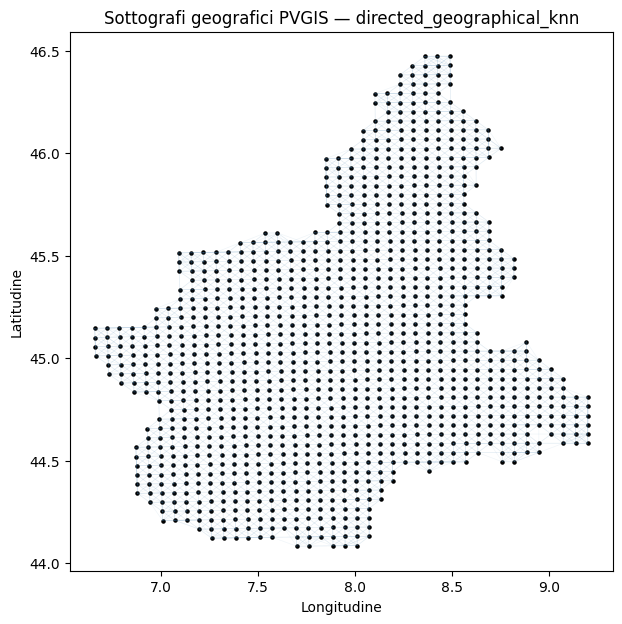

In [5]:
if manifest is not None:
    graph = build_geographical_subgraphs(
        manifest['latitude'].to_numpy(),
        manifest['longitude'].to_numpy(),
        subgraph_size=REFERENCE_CONFIG.subgraph_size,
    )
    print('Indici:', graph.node_indices.shape)
    print('Adiacenze locali:', graph.normalized_adjacency.shape)
    print('Topologia:', graph.topology)
    print(f'Sigma paper: {graph.sigma_km:.3f} km')
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(manifest['longitude'], manifest['latitude'], s=5, color='black')
    for source in range(len(manifest)):
        for target in graph.node_indices[source, 1:]:
            ax.plot(
                manifest.loc[[source, target], 'longitude'],
                manifest.loc[[source, target], 'latitude'],
                color='steelblue', alpha=0.08, linewidth=0.5,
            )
    ax.set(title=f'Sottografi geografici PVGIS — {graph.topology}', xlabel='Longitudine', ylabel='Latitudine')
    plt.show()

## 3. Smoke test opzionale

Questa configurazione ridotta verifica soltanto l'integrazione. Non è una configurazione scientifica del paper perché usa nove località, una sola epoca e campionamento storico.

In [6]:
smoke_config = replace(
    REFERENCE_CONFIG,
    epochs=1,
    batch_size=32,
    train_samples_per_epoch=512,
    score_stride=24,
)
if RUN_SMOKE:
    run_stgan(
        manifest_path=MANIFEST,
        out_dir=SMOKE_OUTPUT,
        paper_top_k_percent=PAPER_TOP_K_PERCENT,
        config=smoke_config,
        device=DEVICE,
        max_locations=9,
    )

[stgan] seed=20 locations=9 features=['solar_irradiance_poa', 'temperature_2m', 'wind_speed_10m']
[stgan] epoch=1/1 batch=1/16 D=0.694033 G=201.532089
[stgan] epoch=1/1 batch=2/16 D=0.691040 G=208.783493
[stgan] epoch=1/1 batch=3/16 D=0.689471 G=187.483627
[stgan] epoch=1/1 batch=4/16 D=0.687367 G=189.910919
[stgan] epoch=1/1 batch=5/16 D=0.686170 G=173.333862
[stgan] epoch=1/1 batch=6/16 D=0.686356 G=159.351822
[stgan] epoch=1/1 batch=7/16 D=0.682866 G=153.873367
[stgan] epoch=1/1 batch=8/16 D=0.683764 G=135.405045
[stgan] epoch=1/1 batch=9/16 D=0.683905 G=124.106232
[stgan] epoch=1/1 batch=10/16 D=0.681380 G=111.987747
[stgan] epoch=1/1 batch=11/16 D=0.682566 G=100.946358
[stgan] epoch=1/1 batch=12/16 D=0.683019 G=87.909828
[stgan] epoch=1/1 batch=13/16 D=0.682203 G=71.418602
[stgan] epoch=1/1 batch=14/16 D=0.685591 G=63.298477
[stgan] epoch=1/1 batch=15/16 D=0.688447 G=61.799282
[stgan] epoch=1/1 batch=16/16 D=0.690016 G=56.284481


## 4. Run di riferimento paper-aligned

La configurazione di riferimento visita l'intero prodotto tempo×località a ogni epoca, come il repository ufficiale. È estremamente costosa su 14 anni e 1.149 località. `PAPER_TOP_K_PERCENT` dichiara soltanto il budget globale di punti restituiti come anomalie; non modifica training o score.

In [7]:
if RUN_REFERENCE:
    run_stgan(
        manifest_path=MANIFEST,
        out_dir=REFERENCE_OUTPUT,
        paper_top_k_percent=PAPER_TOP_K_PERCENT,
        config=REFERENCE_CONFIG,
        device=DEVICE,
        seeds=(REFERENCE_SEED,),
    )

[stgan] seed=20 locations=1149 features=['solar_irradiance_poa', 'temperature_2m', 'wind_speed_10m']
[stgan] epoch=1/6 batch=27500/550012 D=0.655684 G=2.613203
[stgan] epoch=1/6 batch=55000/550012 D=0.650763 G=3.322157
[stgan] epoch=1/6 batch=82500/550012 D=0.631347 G=3.210351
[stgan] epoch=1/6 batch=110000/550012 D=0.632793 G=2.447272
[stgan] epoch=1/6 batch=137500/550012 D=0.625518 G=2.202168
[stgan] epoch=1/6 batch=165000/550012 D=0.614097 G=3.718019
[stgan] epoch=1/6 batch=192500/550012 D=0.639507 G=2.288040
[stgan] epoch=1/6 batch=220000/550012 D=0.621022 G=2.050255
[stgan] epoch=1/6 batch=247500/550012 D=0.611818 G=3.403935
[stgan] epoch=1/6 batch=275000/550012 D=0.583904 G=3.253349
[stgan] epoch=1/6 batch=302500/550012 D=0.603281 G=3.347883
[stgan] epoch=1/6 batch=330000/550012 D=0.598394 G=3.117411
[stgan] epoch=1/6 batch=357500/550012 D=0.586467 G=3.055077
[stgan] epoch=1/6 batch=385000/550012 D=0.578123 G=3.694912
[stgan] epoch=1/6 batch=412500/550012 D=0.593298 G=3.035113
[s

## 5. Analisi spaziale dei risultati

`anomaly_scores.csv` mantiene il formato comune ai detector. Le coordinate vengono aggiunte con un join a `locations.csv`, evitando di ripeterle per milioni di righe.

In [8]:
ANALYSIS_ROOT = REFERENCE_OUTPUT
SEED = 20
score_path = ANALYSIS_ROOT / f'seed_{SEED}' / 'anomaly_scores.csv'
locations_path = ANALYSIS_ROOT / 'locations.csv'
feature_path = ANALYSIS_ROOT / f'seed_{SEED}' / 'entity_anomaly_scores.csv'

if score_path.is_file() and locations_path.is_file():
    scores = pd.read_csv(score_path, parse_dates=['timestamp'])
    locations = pd.read_csv(locations_path)
    spatial = scores.merge(locations, on='location', how='left', validate='many_to_one')
    assert spatial[['latitude', 'longitude']].notna().all().all()
    display(spatial.head())
    print(f'Punti valutati: {len(spatial):,}; anomalie: {spatial.is_anomaly.sum():,}')
else:
    scores = spatial = None
    print('Output di riferimento non ancora disponibile.')

,location,timestamp,method,anomaly_score,global_rank,global_percentile,threshold,is_anomaly,site_key,latitude,longitude
0,0,2019-01-01 00:10:00,stgan,0.509440,3872581.0,61.525210,NaN,False,loc_0000_0,44.082303,7.698273
1,0,2019-01-01 01:10:00,stgan,0.538421,1331719.0,86.769138,NaN,False,loc_0000_0,44.082303,7.698273
2,0,2019-01-01 02:10:00,stgan,0.506009,4181787.0,58.453191,NaN,False,loc_0000_0,44.082303,7.698273
3,0,2019-01-01 03:10:00,stgan,0.498830,4700538.0,53.299305,NaN,False,loc_0000_0,44.082303,7.698273
4,0,2019-01-01 04:10:00,stgan,0.510291,3791219.0,62.333556,NaN,False,loc_0000_0,44.082303,7.698273


Punti valutati: 10,065,240; anomalie: 100,653


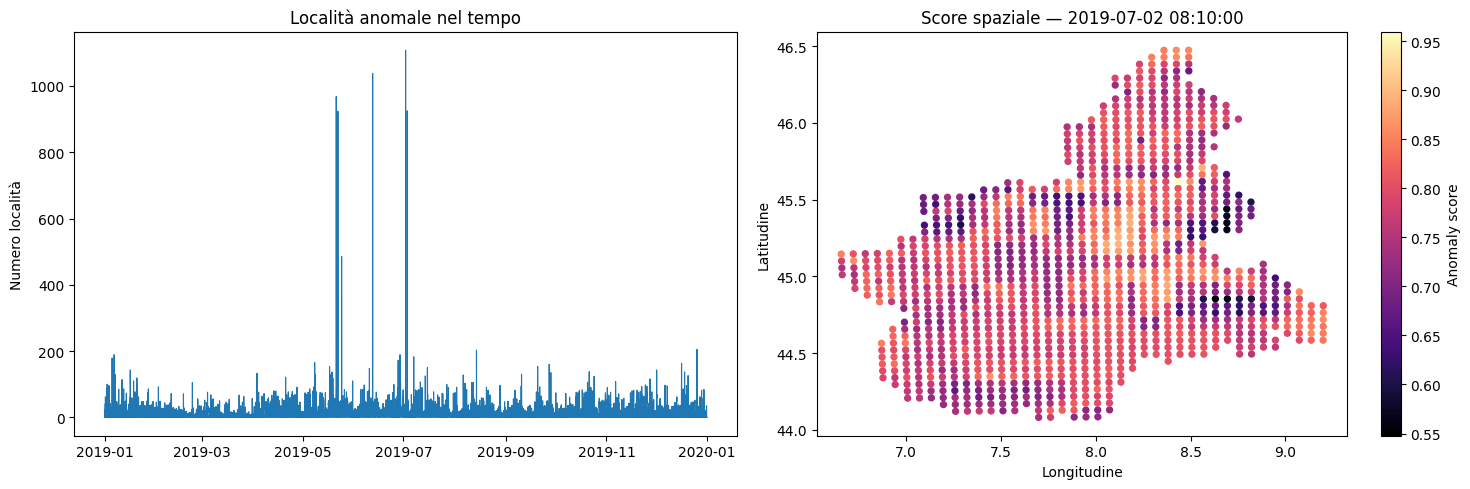

,entity,contribution_fraction
0,solar_irradiance_poa,0.751471
1,temperature_2m,0.164414
2,wind_speed_10m,0.084115


In [9]:
if spatial is not None:
    hourly = spatial.groupby('timestamp', as_index=False).agg(
        mean_score=('anomaly_score', 'mean'),
        anomalous_locations=('is_anomaly', 'sum'),
    )
    focus_time = hourly.nlargest(1, 'anomalous_locations').iloc[0]['timestamp']
    focus = spatial.loc[spatial['timestamp'].eq(focus_time)]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(hourly['timestamp'], hourly['anomalous_locations'], linewidth=0.8)
    axes[0].set(title='Località anomale nel tempo', ylabel='Numero località')
    points = axes[1].scatter(
        focus['longitude'], focus['latitude'], c=focus['anomaly_score'],
        s=18, cmap='magma',
    )
    axes[1].set(title=f'Score spaziale — {focus_time}', xlabel='Longitudine', ylabel='Latitudine')
    fig.colorbar(points, ax=axes[1], label='Anomaly score')
    plt.tight_layout()
    plt.show()

if feature_path.is_file():
    feature_scores = pd.read_csv(feature_path, parse_dates=['timestamp'])
    display(
        feature_scores.groupby('entity', as_index=False)['contribution_fraction']
        .mean().sort_values('contribution_fraction', ascending=False)
    )

## 6. Sensibilità al top-K% del paper

STGAN viene addestrato una sola volta. I valori di `K` cambiano esclusivamente il taglio applicato al ranking globale già salvato: per ogni `K`, sono anomali i primi `ceil(K% × N)` punti. La griglia seguente è fissa e non modifica modello, score o normalizzazione.

In [10]:
K_PERCENTAGES = np.array([0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])
SENSITIVITY_OUTPUT = ANALYSIS_ROOT / 'top_k_sensitivity'

def top_k_summary(score_frame, percentages):
    finite = score_frame.loc[
        np.isfinite(score_frame['anomaly_score']) & np.isfinite(score_frame['global_rank'])
    ].copy()
    if finite.empty:
        raise ValueError('Nessuno score STGAN finito disponibile.')
    if finite['global_rank'].duplicated().any():
        raise ValueError('Il ranking globale STGAN deve essere univoco.')
    n_points = len(finite)
    rows = []
    for percentage in percentages:
        budget = min(n_points, max(1, int(np.ceil(n_points * percentage / 100.0))))
        selected = finite['global_rank'].le(budget)
        rows.append({
            'k_percent': float(percentage),
            'n_anomaly': int(selected.sum()),
            'anomaly_fraction': float(selected.mean()),
            'score_cutoff': float(finite.loc[selected, 'anomaly_score'].min()),
        })
    return pd.DataFrame(rows)

if scores is not None:
    top_k = top_k_summary(scores, K_PERCENTAGES)
    SENSITIVITY_OUTPUT.mkdir(parents=True, exist_ok=True)
    top_k.to_csv(SENSITIVITY_OUTPUT / 'top_k_summary.csv', index=False)
    display(top_k)
else:
    top_k = None

,k_percent,n_anomaly,anomaly_fraction,score_cutoff
0,0.2,20131,0.002,0.769585
1,0.5,50327,0.005,0.703880
2,1.0,100653,0.010,0.655332
3,1.5,150979,0.015,0.627805
4,2.0,201305,0.020,0.609373
5,3.0,301958,0.030,0.585836
6,5.0,503262,0.050,0.563924


## 7. Errore multihorizon al variare di K

La classificazione STGAN viene associata al `timestamp` target della previsione, non a `issue_timestamp`. Il CSV viene letto a blocchi per mantenere limitato l'uso di memoria e le metriche sono calcolate sui campioni diurni (`solar_irradiance_poa_target > 10 W/m²`), evitando che gli zeri notturni dominino il confronto. Le curve coprono tutti gli orizzonti SDE diretti da `t+1` a `t+6`.

In [11]:
MULTIHORIZON_PREDICTIONS = (
    ROOT / 'outputs' / 'pvgis_stgnn_multihorizon_t1_t6' / 'predictions.csv'
)
FORECAST_HORIZONS = tuple(range(1, 7))
DAYTIME_THRESHOLD_WM2 = 10.0

def multihorizon_top_k_metrics(prediction_path, score_frame, percentages, horizons):
    header = set(pd.read_csv(prediction_path, nrows=0).columns)
    prediction_column = 'y_pred_mean' if 'y_pred_mean' in header else 'y_pred'
    required = {
        'location', 'timestamp', 'horizon_hours', 'y_true', prediction_column,
        'solar_irradiance_poa_target',
    }
    missing = required - header
    if missing:
        raise ValueError(f'Colonne multihorizon mancanti: {sorted(missing)}')

    score_lookup = score_frame[['location', 'timestamp', 'global_rank']].copy()
    score_lookup['location'] = score_lookup['location'].astype(str)
    score_lookup['timestamp'] = pd.to_datetime(score_lookup['timestamp']).dt.tz_localize(None)
    if score_lookup.duplicated(['location', 'timestamp']).any():
        raise ValueError('Score STGAN duplicati per location e timestamp.')
    n_scores = int(score_lookup['global_rank'].notna().sum())
    budgets = {
        float(k): min(n_scores, max(1, int(np.ceil(n_scores * k / 100.0))))
        for k in percentages
    }
    totals = {}
    requested = set(horizons)
    n_requested = n_matched = 0
    usecols = [
        'location', 'timestamp', 'horizon_hours', 'y_true', prediction_column,
        'solar_irradiance_poa_target',
    ]

    for chunk in pd.read_csv(prediction_path, usecols=usecols, chunksize=500_000):
        chunk = chunk.loc[chunk['horizon_hours'].isin(requested)].copy()
        chunk = chunk.loc[
            chunk['solar_irradiance_poa_target'] > DAYTIME_THRESHOLD_WM2
        ].copy()
        if chunk.empty:
            continue
        n_requested += len(chunk)
        chunk['location'] = chunk['location'].astype(str)
        chunk['timestamp'] = pd.to_datetime(chunk['timestamp']).dt.tz_localize(None)
        joined = chunk.merge(
            score_lookup, on=['location', 'timestamp'], how='left', validate='many_to_one'
        )
        finite = np.isfinite(
            joined[['y_true', prediction_column, 'global_rank']].to_numpy(dtype=float)
        ).all(axis=1)
        joined = joined.loc[finite]
        n_matched += len(joined)
        error = joined[prediction_column].to_numpy(float) - joined['y_true'].to_numpy(float)
        absolute = np.abs(error)
        squared = error * error
        ranks = joined['global_rank'].to_numpy(float)
        horizon_values = joined['horizon_hours'].to_numpy(int)

        for k, budget in budgets.items():
            anomalous = ranks <= budget
            for horizon in horizons:
                at_horizon = horizon_values == horizon
                for group, group_mask in (('normal', ~anomalous), ('anomaly', anomalous)):
                    mask = at_horizon & group_mask
                    key = (k, horizon, group)
                    count, sum_absolute, sum_squared = totals.get(key, (0, 0.0, 0.0))
                    totals[key] = (
                        count + int(mask.sum()),
                        sum_absolute + float(absolute[mask].sum()),
                        sum_squared + float(squared[mask].sum()),
                    )

    rows = []
    for (k, horizon, group), (count, sum_absolute, sum_squared) in totals.items():
        rows.append({
            'k_percent': k, 'horizon_hours': horizon, 'group': group, 'n': count,
            'mae': sum_absolute / count if count else np.nan,
            'rmse': np.sqrt(sum_squared / count) if count else np.nan,
        })
    coverage = n_matched / n_requested if n_requested else 0.0
    return pd.DataFrame(rows).sort_values(['horizon_hours', 'k_percent', 'group']), coverage

if scores is not None and MULTIHORIZON_PREDICTIONS.is_file():
    horizon_metrics, join_coverage = multihorizon_top_k_metrics(
        MULTIHORIZON_PREDICTIONS, scores, K_PERCENTAGES, FORECAST_HORIZONS
    )
    if join_coverage < 0.95:
        raise ValueError(f'Copertura join STGAN/multihorizon insufficiente: {join_coverage:.1%}')
    horizon_metrics.to_csv(SENSITIVITY_OUTPUT / 'forecast_error_by_top_k.csv', index=False)
    display(horizon_metrics)
else:
    horizon_metrics = None
    print('Predizioni multihorizon non trovate:', MULTIHORIZON_PREDICTIONS)

Predizioni multihorizon non trovate: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_multihorizon_t1_t6/predictions.csv


In [12]:
if horizon_metrics is not None and not horizon_metrics.empty:
    available = tuple(sorted(horizon_metrics['horizon_hours'].unique()))
    missing_horizons = sorted(set(FORECAST_HORIZONS) - set(available))
    if missing_horizons:
        print('Orizzonti non presenti nel CSV:', missing_horizons)
    fig, axes = plt.subplots(2, len(available), figsize=(5 * len(available), 9), squeeze=False)
    for column, horizon in enumerate(available):
        subset = horizon_metrics.loc[horizon_metrics['horizon_hours'].eq(horizon)]
        for row, metric in enumerate(('mae', 'rmse')):
            ax = axes[row, column]
            for group, label in (('normal', 'Normali'), ('anomaly', 'Anomali')):
                curve = subset.loc[subset['group'].eq(group)]
                ax.plot(curve['k_percent'], curve[metric], marker='o', label=label)
            ax.axvline(PAPER_TOP_K_PERCENT, color='black', linestyle='--', alpha=0.6)
            ax.set(
                title=f't+{horizon}h — {metric.upper()}',
                xlabel='Top-K globale [%]', ylabel=metric.upper(),
            )
            ax.grid(alpha=0.25)
            ax.legend()
    plt.tight_layout()
    fig.savefig(SENSITIVITY_OUTPUT / 'forecast_error_vs_top_k.png', dpi=180, bbox_inches='tight')
    plt.show()

## 8. Heatmap della classificazione per K

La mappa usa lo stesso ranking globale dello sweep. Il timestamp mostrato è quello con il maggior numero di località comprese nel top-K selezionato.

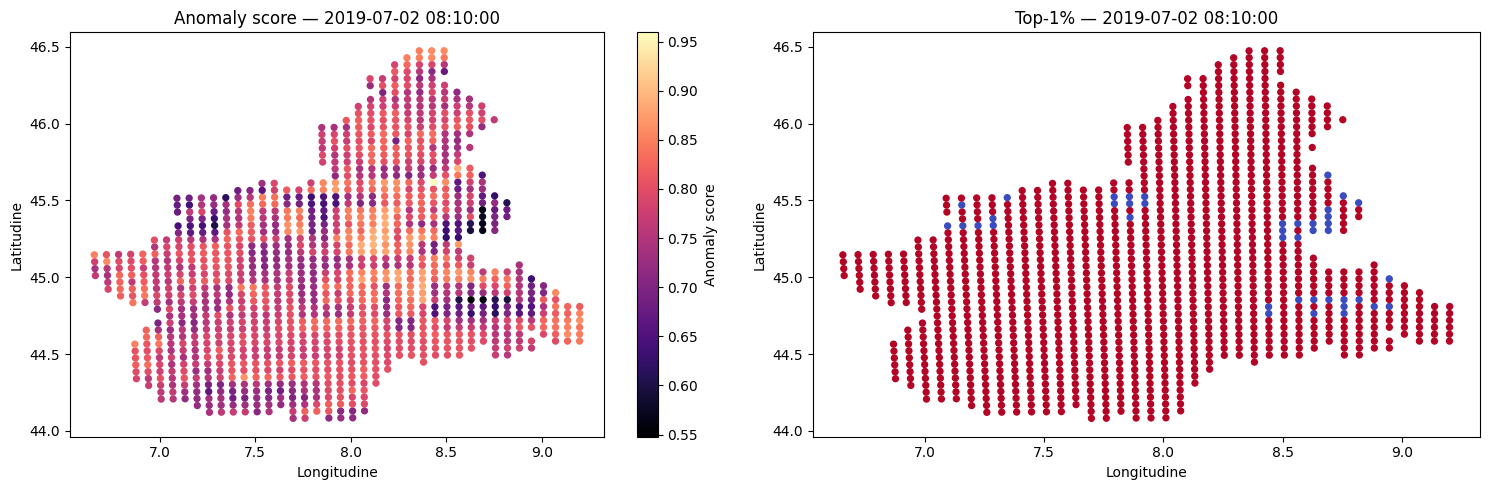

In [13]:
HEATMAP_K_PERCENT = 1.0
if spatial is not None:
    n_scores = int(spatial['global_rank'].notna().sum())
    heatmap_budget = min(
        n_scores, max(1, int(np.ceil(n_scores * HEATMAP_K_PERCENT / 100.0)))
    )
    spatial_k = spatial.copy()
    spatial_k['is_anomaly_k'] = spatial_k['global_rank'].le(heatmap_budget)
    counts = spatial_k.groupby('timestamp')['is_anomaly_k'].sum()
    heatmap_time = counts.idxmax()
    heatmap = spatial_k.loc[spatial_k['timestamp'].eq(heatmap_time)]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    score_points = axes[0].scatter(
        heatmap['longitude'], heatmap['latitude'], c=heatmap['anomaly_score'],
        s=18, cmap='magma',
    )
    axes[0].set(title=f'Anomaly score — {heatmap_time}', xlabel='Longitudine', ylabel='Latitudine')
    fig.colorbar(score_points, ax=axes[0], label='Anomaly score')
    axes[1].scatter(
        heatmap['longitude'], heatmap['latitude'],
        c=heatmap['is_anomaly_k'].astype(int), s=18, cmap='coolwarm', vmin=0, vmax=1,
    )
    axes[1].set(
        title=f'Top-{HEATMAP_K_PERCENT:g}% — {heatmap_time}',
        xlabel='Longitudine', ylabel='Latitudine',
    )
    plt.tight_layout()
    fig.savefig(SENSITIVITY_OUTPUT / 'spatial_top_k_heatmap.png', dpi=180, bbox_inches='tight')
    plt.show()